In [2]:
import dipy
import os
import subprocess
import nibabel as nib
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.io.image import load_nifti, save_nifti
from dipy.reconst.dti import TensorModel
from dipy.align.imaffine import AffineMap, MutualInformationMetric, AffineRegistration
from dipy.align.transforms import TranslationTransform3D, RigidTransform3D
import os
import sys
sys.path.append('../../' \
'')
from cardpy.Sample_Data.Data_Paths                  import *
from cardpy.Data_Sorting                            import *
from cardpy.Data_Saving                             import *
from cardpy.Data_Processing.Gibbs                   import *
from cardpy.Data_Processing.Registration            import *
from cardpy.Data_Processing.Rejection               import *
from cardpy.Data_Processing.Respiratory             import *
from cardpy.Data_Processing.Diffusivity             import *
from cardpy.Data_Processing.Averaging               import *
from cardpy.Data_Processing.Denoising               import *
from cardpy.Data_Processing.Interpolation           import *
from cardpy.Data_Processing.Segmentation_Matrix_DTI import *
from cardpy.Sample_Data.Data_Paths import *
from cardpy.Data_Import            import *
from cardpy.Data_Sorting           import *
from cardpy.Data_Processing.DTI    import *
from cardpy.Data_Processing.DWI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from cardpy.Data_Saving            import *
from cardpy.Data_Processing.cDTI   import *
from cardpy.GUI_Tools                     import *
from cardpy.Colormaps                     import *
from cardpy.Data_Processing.DTI    import *
from cardpy.GUI_Tools              import IntERCOMS
from cardpy.Colormaps              import *
from matplotlib import pyplot as plt
import os
import subprocess
import nibabel as nib
import numpy as np
import glob
from scipy.io import savemat



In [3]:
# -----------------------------
# Configuration
# -----------------------------
volunteer_id = 'Phantom_gel_DTI' #'V001'
mode = 'Phantom' # 'InVivo' or 'Phantom'

In [4]:
# -----------------------------
# Base paths and volunteer
# -----------------------------
base_path = '/Volumes/T7/Stim-CODE/Raw'
out_main = '/Volumes/T7/Stim-CODE/NifTi'  # <--- define your output root

if mode.lower() == 'phantom':
    registration_algorithm = 'Rigid'
elif mode.lower() == 'invivo': # case insensitive
    registration_algorithm = 'Affine'

volunteer_path = os.path.join(base_path, volunteer_id)
if not os.path.exists(volunteer_path):
    raise FileNotFoundError(f"Volunteer folder not found: {volunteer_path}")

# Ensure volunteer output folder exists
vol_out_path = os.path.join(out_main, volunteer_id)
os.makedirs(vol_out_path, exist_ok=True)

Found 28 scans for Phantom_gel_DTI

Processing scan: meas_MID00154_FID19344_ep2d_diff_m0_ext_b1000_sos_mmt0 (b=1000)
  Loading meas_MID00154_FID19344_ep2d_diff_m0_ext_b1000_sos_mmt0 (1 slices)
  Output path: /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_DTI/ep2d_diff_m0_ext_b1000_sos_mmt0
    Done. Shape = (146, 146, 1, 31)
meas_mid00154_fid19344_ep2d_diff_m0_ext_b1000_sos_mmt0
EP2D detected: flipping matrix in y-direction


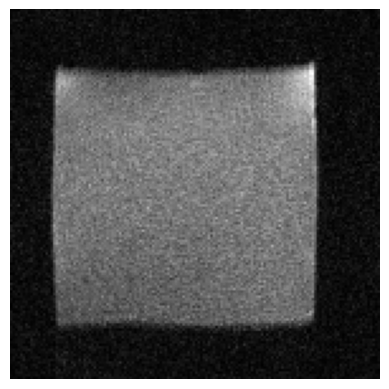

IndexError: index 31 is out of bounds for axis 0 with size 31

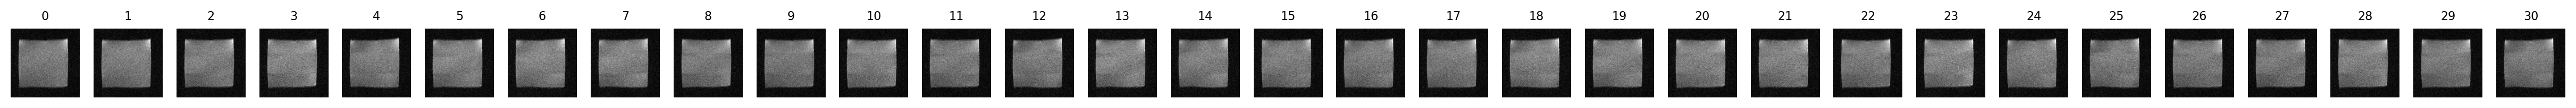

In [5]:
import os
import re
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Prepare output storage
# -----------------------------
data_all = {volunteer_id: {}}

# -----------------------------
# Utility functions
# -----------------------------
def extract_slice_number(filename):
    match = re.search(r'slice(\d+)', filename)
    return int(match.group(1)) if match else -1

def extract_scan_suffix(scan_name):
    """Extract part after FIDxxxxx_ for folder naming"""
    match = re.search(r'FID\d+_(.*)', scan_name)
    return match.group(1) if match else scan_name

# -----------------------------
# Iterate through scan folders
# -----------------------------
scan_folders = [d for d in os.listdir(volunteer_path)
                if os.path.isdir(os.path.join(volunteer_path, d))
                and d.startswith("meas_")]

print(f"Found {len(scan_folders)} scans for {volunteer_id}\n")

for scan in scan_folders:
    scan_path = os.path.join(volunteer_path, scan)
    slice_path = os.path.join(scan_path, 'coil_combine_slices')

    if not os.path.exists(slice_path):
        print(f"Skipping {scan}: no coil_combine_slices folder")
        continue

    # Extract suffix for output folder
    scan_suffix = extract_scan_suffix(scan)
    scan_out_path = os.path.join(vol_out_path, scan_suffix)
    os.makedirs(scan_out_path, exist_ok=True)
    out_path = scan_out_path
    

    bval = 1000
    print(f"Processing scan: {scan} (b={bval})")
    # -----------------------------
    # Find and sort slice files
    # -----------------------------
    all_files = [f for f in os.listdir(slice_path)
                 if f.startswith("coil_combine_slice") and f.endswith(".mat")]

    if not all_files:
        print(f"Skipping {scan}: no matching slice .mat files found")
        continue

    file_list = sorted(all_files, key=extract_slice_number)
    print(f"  Loading {scan} ({len(file_list)} slices)")
    print(f"  Output path: {scan_out_path}")

    # -----------------------------
    # Load first slice to get shape
    # -----------------------------
    first_file = os.path.join(slice_path, file_list[0])
    with h5py.File(first_file, "r") as f:
        tmp = f["im_coil_combine"][:]
        tmp = tmp["real"] + 1j * tmp["imag"]
        tmp = np.array(tmp)
        nreps, nx, ny = tmp.shape  # expected [Nreps, Nx, Ny]

    nSlices = len(file_list)
    data = np.zeros((nx, ny, nSlices, nreps), dtype=np.complex128)

    # -----------------------------
    # Load all slices
    # -----------------------------
    for s, fname in enumerate(file_list):
        path = os.path.join(slice_path, fname)
        with h5py.File(path, "r") as f:
            tmp = f["im_coil_combine"][:]
            tmp = tmp["real"] + 1j * tmp["imag"]
            tmp = np.array(tmp)
            tmp = np.transpose(tmp, (1, 2, 0))  # [Nx, Ny, Nreps]
            data[:, :, s, :] = tmp

    # -----------------------------
    # Store in dictionary
    # -----------------------------
    data_all[volunteer_id][scan] = data
    print(f"    Done. Shape = {data.shape}")


    # Set up General Parameters
    operation_type = 'Complex'
    temporary_denoising       = 'OFF'

    Nrep = 10

    b_vecs = [
        [0, 0, 0],
        [0.668583, 0.668583, -0.325568],
        [0.662784, -0.337216, 0.668583],
        [-0.337216, 0.662784, 0.668583]
                                    ] * Nrep

    b_vals = [0] + [bval] * (len(b_vecs)-1)

    Header = {'Manufacturer': 'Siemens Healthineers', 
            'Scanner Model': 'CIMA.X', 
            'Magnet Strength': '3.0', 
            'Patient ID': 'TEST', 
            'Patient Age': 'XX', 
            'Patient Sex': 'X', 
            'Body Part': 'BRAIN', 
            'X Resolution': '1.5', 
            'Y Resolution': '1.5', 
            'Z Resolution': '1.5', 
            'Partial Fourier': '6/8', 
    }

    [temporary_matrix_stacked, temporary_bvals_stacked, temporary_bvecs_stacked] = sorted2stacked(data[:,:,:,:,np.newaxis],b_vals,b_vecs)

    # if scan contains 'ep2d' need to flip
    print(scan.lower())
    if 'ep2d' in scan.lower():
        print('EP2D detected: flipping matrix in y-direction')
        temporary_matrix_stacked = np.flip(temporary_matrix_stacked, axis=1)

    plt.imshow(np.abs(temporary_matrix_stacked[:,:,0,1]), cmap='gray',vmin = 0)
    plt.axis('off')
    plt.show()


    # Example array
    # matrix_sorted = np.random.rand(146, 146, 1, 40)  # your actual data

    num_imgs = temporary_matrix_stacked.shape[3]

    fig, axes = plt.subplots(1, num_imgs, figsize=(num_imgs * 1, 3), dpi=200)

    for i in range(40):
        ax = axes[i]
        img = np.squeeze(temporary_matrix_stacked[:, :, 0, i])
        ax.imshow(abs(img), cmap='gray', vmin=0)
        ax.set_title(str(i), fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
   
    ########## DICOM Import Module #################################################################################################################
    counter        = 0
    counter_string = str(counter)
    folder         = counter_string.zfill(2) + '_Original'
    [temporary_matrix_sorted,  temporary_bvals_sorted,  temporary_bvecs_sorted]          = stacked2sorted(temporary_matrix_stacked, 
                                                                                                        temporary_bvals_stacked, 
                                                                                                        temporary_bvecs_stacked)
    print('Matrix Check Size',temporary_matrix_stacked.shape)

    

    output_path = os.path.join(out_path, folder)
    file_name   = 'Original'
    Save_Diffusion_Image_Data(output_path, file_name, Header, temporary_matrix_sorted, temporary_bvals_sorted, temporary_bvecs_sorted)
    del counter_string, folder, output_path
    del temporary_matrix_stacked, temporary_bvals_stacked, temporary_bvecs_stacked
    ################################################################################################################################################
    ########## Gibb's Ringing Module ###############################################################################################################
    counter        = counter + 1
    counter_string = str(counter)
    folder         = counter_string.zfill(2) + '_Unrung'
    print('Gibbs ringing removal mode is on.')
    ### Step 1: Perform Gibb's ringing removal on temporary sorted matrix
    print('Matrix Check Size',temporary_matrix_sorted.shape)
    [unrung_matrix_sorted, unrung_bvals_sorted, unrung_bvecs_sorted] = unrung(temporary_matrix_sorted, 
                                                                            temporary_bvals_sorted, 
                                                                            temporary_bvecs_sorted, 
                                                                            operation_type = operation_type)
    ### Step 2: Save unrung matrix
    output_path = os.path.join(out_path, folder)
    Save_Diffusion_Image_Data(output_path, 'Unrung', Header, unrung_matrix_sorted, unrung_bvals_sorted, unrung_bvecs_sorted)
    ### Step 3: Assign unrung variables to temporary variables to be overwritten
    temporary_matrix_sorted = unrung_matrix_sorted
    temporary_bvals_sorted  = unrung_bvals_sorted
    temporary_bvecs_sorted  = unrung_bvecs_sorted
    ### Step 4: Delete Variables
    del counter_string, folder, output_path
    del unrung_matrix_sorted, unrung_bvals_sorted, unrung_bvecs_sorted



In [ ]:

counter = 1
# -----------------------------
########## Registration Module (Modified for multi-scan single-slice) ###############################################################
counter        = counter + 1
counter_string = str(counter)
folder         = counter_string.zfill(2) + '_Registered_Global'
print('Global registration mode is on.') 

# Step 1: Combine all scans along the last dimension (directions / Nreps)
all_scans = list(data_all[volunteer_id].keys())
nx, ny, nSlices, nreps = data_all[volunteer_id][all_scans[0]].shape
total_reps = sum([data_all[volunteer_id][scan].shape[3] for scan in all_scans])
combined_matrix = np.zeros((nx, ny, 1, total_reps), dtype=np.complex128)  # single slice
combined_bvals = []
combined_bvecs = []

rep_counter = 0
scan_rep_indices = {}

for scan in all_scans:
    scan_suffix = extract_scan_suffix(scan)
    scan_out_path = os.path.join(vol_out_path, scan_suffix)

    # Load gibb's ringing data
    NifTi_path = glob.glob(os.path.join(scan_out_path, '*Unrung','*.nii'))[0]    
    header_path          = glob.glob(os.path.join(scan_out_path, '*Unrung', '*.header'))[0]
    b_values_path        = glob.glob(os.path.join(scan_out_path, '*Unrung', '*.bvals'))[0]
    b_vectors_path       = glob.glob(os.path.join(scan_out_path, '*Unrung', '*.bvecs'))[0]  


    print('Loading scan for global registration:', scan, NifTi_path)
    [matrix_stacked, b_vals_stacked, b_vecs_stacked, Header, _, _] = NifTi_Reader(NifTi_path, b_values_path, b_vectors_path, header_path)

   
    mat = matrix_stacked  # [Nx, Ny, 1, Nreps]
    nreps_scan = mat.shape[3]
    scan_rep_indices[scan] = (rep_counter, rep_counter + nreps_scan)
    combined_matrix[:, :, :, rep_counter:rep_counter + nreps_scan] = mat

    # Make sure bvals and bvecs match Nreps of this scan
    bvals_scan = np.array([0] + [bval] * (nreps_scan - 1))
    bvecs_scan = np.array(b_vecs[:nreps_scan])

    combined_bvals.extend(bvals_scan)
    combined_bvecs.extend(bvecs_scan)

    rep_counter += nreps_scan

# Convert to numpy arrays
combined_bvals = np.array(combined_bvals)
combined_bvecs = np.array(combined_bvecs)

print("Combined matrix shape:", combined_matrix.shape)
print("Combined bvals shape:", combined_bvals.shape)
print("Combined bvecs shape:", combined_bvecs.shape)

# Step 1b: Sort/stack before registration
temporary_matrix_sorted, temporary_bvals_sorted, temporary_bvecs_sorted = stacked2sorted(
    combined_matrix, combined_bvals, combined_bvecs
)
print("Temporary matrix sorted shape:", temporary_matrix_sorted.shape)

# Step 2: Perform global registration
registered_matrix_combined, registered_bvals_combined, registered_bvecs_combined = register(
    temporary_matrix_sorted,
    temporary_bvals_sorted,
    temporary_bvecs_sorted,
    registration_algorithm=registration_algorithm,
    temporary_denoising=temporary_denoising,
    operation_type=operation_type

)

# Step 3: Split registered data back per scan and save
for scan in all_scans:
    start, end = scan_rep_indices[scan]
    print(start,end)
    
    scan_suffix = extract_scan_suffix(scan)
    scan_out_path = os.path.join(vol_out_path, scan_suffix)

    # Slice along last dimension (directions/Nreps)
    registered_matrix_stacked, registered_bvals_stacked, registered_bvecs_stacked = sorted2stacked(
        registered_matrix_combined, registered_bvals_combined, registered_bvecs_combined
    )
    registered_matrix_stacked = registered_matrix_stacked[:, :, :, start:end]  # keep slice axis
    registered_bvals_stacked  = registered_bvals_stacked[start:end]
    registered_bvecs_stacked  = registered_bvecs_stacked[start:end]

    registered_matrix_sorted, registered_bvals_sorted, registered_bvecs_sorted = stacked2sorted(
        registered_matrix_stacked, registered_bvals_stacked, registered_bvecs_stacked
    )

    print(f"Scan: {scan}")
    print(" Registered matrix shape:", registered_matrix_stacked.shape)
    print(" Registered bvals shape:", registered_bvals_stacked.shape)
    print(" Registered bvecs shape:", registered_bvecs_stacked.shape)


    output_path = os.path.join(scan_out_path, folder)
    print('Saving registered data to:', output_path )
    os.makedirs(output_path, exist_ok=True)

    Save_Diffusion_Image_Data(output_path, 'Registered', Header,
                              registered_matrix_sorted, registered_bvals_sorted, registered_bvecs_sorted)

    # Assign back to temporary variables for further processing
    temporary_matrix_sorted = registered_matrix_sorted
    temporary_bvals_sorted  = registered_bvals_sorted
    temporary_bvecs_sorted  = registered_bvecs_sorted


Global registration mode is on.
Loading scan for global registration: meas_MID00072_FID16792_ep2d_diff_m0_ext_b1000_sos_mmt0 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/ep2d_diff_m0_ext_b1000_sos_mmt0/01_Unrung/Unrung.nii
Loading scan for global registration: meas_MID00073_FID16793_gropt_mmt0_Ncalib2 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/gropt_mmt0_Ncalib2/01_Unrung/Unrung.nii
Loading scan for global registration: meas_MID00074_FID16794_trap_mmt0_Ncalib2 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/trap_mmt0_Ncalib2/01_Unrung/Unrung.nii
Loading scan for global registration: meas_MID00075_FID16795_gropt_mmt1_Ncalib2 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/gropt_mmt1_Ncalib2/01_Unrung/Unrung.nii
Combined matrix shape: (146, 146, 1, 160)
Combined bvals shape: (160,)
Combined bvecs shape: (160, 3)
Temporary matrix sorted shape: (146, 146, 1, 4, 40)
Temporary denoising is turned off.
Registering diffusion directions to first diffusion direction (b = 0) for each average.

Processing averaging and DWI reconstruction for scan: meas_MID00072_FID16792_ep2d_diff_m0_ext_b1000_sos_mmt0 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/ep2d_diff_m0_ext_b1000_sos_mmt0
Averaging mode is on.
Re-registering data after data averaging.
Temporary denoising is turned off.
Registering diffusion directions to first diffusion direction (b = 0) for each average.
Registering first diffusion direction (b = 0) to each average first diffusion direction (b = 0).
Finished registration.
output_path /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/ep2d_diff_m0_ext_b1000_sos_mmt0/03_Averaged


/Users/ariel/Documents/GitHub/stim_code/Experiment_Code/01_Processing/../../cardpy/Data_Processing/DWI.py:47: RuntimeWarning: divide by zero encountered in log
  D_zz                             = -(1 / b) * np.log(S_z / S_0)                                                             # Calculate z diffusion coefficient


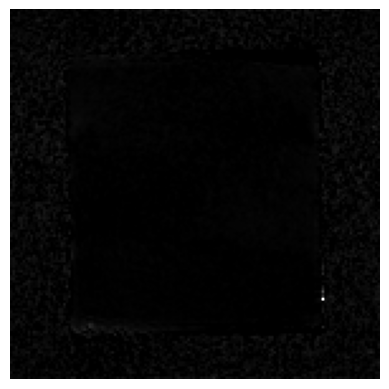

Processing averaging and DWI reconstruction for scan: meas_MID00073_FID16793_gropt_mmt0_Ncalib2 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/gropt_mmt0_Ncalib2
Averaging mode is on.
Re-registering data after data averaging.
Temporary denoising is turned off.
Registering diffusion directions to first diffusion direction (b = 0) for each average.
Registering first diffusion direction (b = 0) to each average first diffusion direction (b = 0).
Finished registration.
output_path /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/gropt_mmt0_Ncalib2/03_Averaged


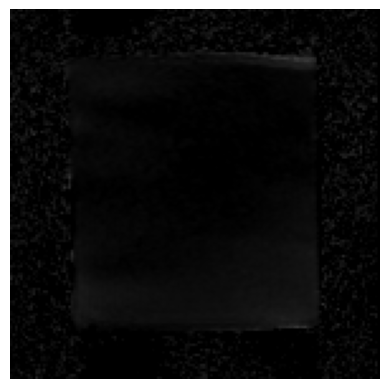

Processing averaging and DWI reconstruction for scan: meas_MID00074_FID16794_trap_mmt0_Ncalib2 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/trap_mmt0_Ncalib2
Averaging mode is on.
Re-registering data after data averaging.
Temporary denoising is turned off.
Registering diffusion directions to first diffusion direction (b = 0) for each average.
Registering first diffusion direction (b = 0) to each average first diffusion direction (b = 0).
Finished registration.
output_path /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/trap_mmt0_Ncalib2/03_Averaged


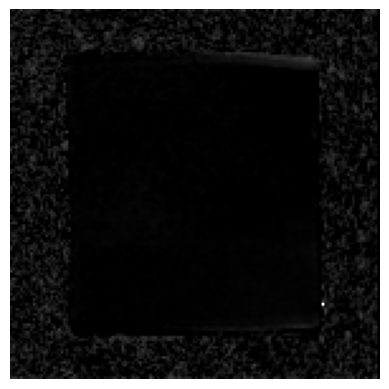

Processing averaging and DWI reconstruction for scan: meas_MID00075_FID16795_gropt_mmt1_Ncalib2 /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/gropt_mmt1_Ncalib2
Averaging mode is on.
Re-registering data after data averaging.
Temporary denoising is turned off.
Registering diffusion directions to first diffusion direction (b = 0) for each average.
Registering first diffusion direction (b = 0) to each average first diffusion direction (b = 0).
Finished registration.
output_path /Volumes/T7/Stim-CODE/NifTi/Phantom_gel_repeat/gropt_mmt1_Ncalib2/03_Averaged


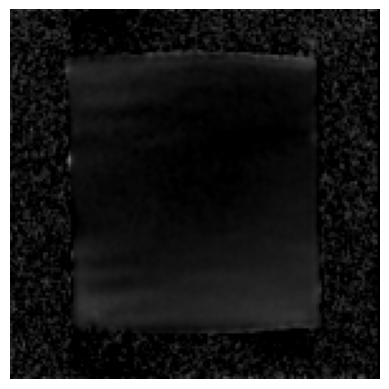


✅ All available scans loaded for Phantom_gel_repeat


In [ ]:
counter = 2
for scan in scan_folders:
    scan_suffix = extract_scan_suffix(scan)
    scan_out_path = os.path.join(vol_out_path, scan_suffix)
    out_path = scan_out_path
    print(f"Processing averaging and DWI reconstruction for scan: {scan}"  , scan_out_path)

    
    # -----------------------------
    # Registered  nifti path 
    NifTi_path = glob.glob(os.path.join(scan_out_path, '*Registered_Global','Registered.nii'))[0]    
    header_path          = glob.glob(os.path.join(scan_out_path, '*Registered_Global', '*.header'))[0]
    b_values_path        = glob.glob(os.path.join(scan_out_path, '*Registered_Global', '*.bvals'))[0]
    b_vectors_path       = glob.glob(os.path.join(scan_out_path, '*Registered_Global', '*.bvecs'))[0]  

    [matrix_stacked, b_vals_stacked, b_vecs_stacked, Header, _, _] = NifTi_Reader(NifTi_path, b_values_path, b_vectors_path, header_path)

    [temporary_matrix_sorted,  temporary_bvals_sorted,  temporary_bvecs_sorted]          = stacked2sorted(matrix_stacked, 
                                                                                                        b_vals_stacked, 
                                                                                                        b_vecs_stacked)
    ################################################################################################################################################
    
    ########## Averaging Module ####################################################################################################################
    counter        = 3
    counter_string = str(counter)
    folder         = counter_string.zfill(2) + '_Averaged'
    print('Averaging mode is on.')
    ### Step 1: Perform averaging on temporary sorted matrix
    [averaged_matrix_sorted, averaged_bvals_sorted, averaged_bvecs_sorted] = average(temporary_matrix_sorted, 
                                                                                        temporary_bvals_sorted, 
                                                                                        temporary_bvecs_sorted,
                                                                                        operation_type = operation_type)
    print('Re-registering data after data averaging.')
    ### Step 2: Perform registration on average sorted matrix
    [registered_matrix_sorted, registered_bvals_sorted, registered_bvecs_sorted] = register(averaged_matrix_sorted,
                                                                                            averaged_bvals_sorted, 
                                                                                            averaged_bvecs_sorted, 
                                                                                            registration_algorithm = registration_algorithm,
                                                                                            temporary_denoising    = temporary_denoising,
                                                                                            operation_type         = operation_type)
    ### Step 3: Save averaged stacked matrix (DiPy format)
    output_path = os.path.join(out_path, folder)
    print('output_path',output_path)
    Save_Diffusion_Image_Data(output_path, 'Averaged', Header, np.real(registered_matrix_sorted), registered_bvals_sorted, registered_bvecs_sorted)
    ### Step 4: Assign registered stacked variables to temporary variables to be overwritten
    temporary_matrix_sorted = registered_matrix_sorted
    temporary_bvals_sorted  = registered_bvals_sorted
    temporary_bvecs_sorted  = registered_bvecs_sorted
    ### Step 5: Delete Variables
    del counter_string, folder, output_path
    del averaged_matrix_sorted, averaged_bvals_sorted, averaged_bvecs_sorted 
    del registered_matrix_sorted, registered_bvals_sorted, registered_bvecs_sorted

    
    ########## # DWI Reconstruction Module ##############################################################################################################
    counter        = 4
    counter_string = str(counter)
    folder         = counter_string.zfill(2) + '_DWI_Results'

    NifTi_path               = glob.glob(os.path.join(out_path, '*Averaged', '*.nii'))[0]
    header_path              = glob.glob(os.path.join(out_path, '*Averaged', '*.header'))[0]
    b_values_path            = glob.glob(os.path.join(out_path, '*Averaged', '*.bvals'))[0]
    b_vectors_path           = glob.glob(os.path.join(out_path, '*Averaged', '*.bvecs'))[0]

    [matrix_stacked, b_vals_stacked, b_vecs_stacked, Header, _, _] = NifTi_Reader(NifTi_path, b_values_path, b_vectors_path, header_path)
    [matrix_sorted,  b_vals_sorted,  b_vecs_sorted]                = stacked2sorted(matrix_stacked, b_vals_stacked, b_vecs_stacked)
    # Take the real part of the matrix and scale it
    #matrix_sorted = np.real(matrix_sorted) * 1e3
    
    mat = np.real(matrix_sorted)
    min_val = mat.min()
    max_val = mat.max()

    if max_val > min_val:
        matrix_rescaled = (mat - min_val) / (max_val - min_val) * 1000
    else:
        # all values identical → set to 0 or any constant
        matrix_rescaled = np.zeros_like(mat)
   
   
    matrix_sorted = np.flip(matrix_rescaled, axis=0)  

    b_vecs_sorted = b_vecs_sorted
    norms = np.linalg.norm(np.array(b_vecs_sorted), axis=1, keepdims=True)
    b_vecs_sorted = np.divide(b_vecs_sorted, norms, out=np.zeros_like(b_vecs_sorted), where=norms != 0)

    Standard_DWI_Metrics = DWI_recon(matrix_sorted, b_vals_sorted, b_vecs_sorted)
    output_path = os.path.join(out_path, folder)
    os.makedirs(output_path, exist_ok=True)

    string = 'Standard_DWI_Metrics'
    outpath = os.path.join(output_path,  string + '.mat')
    savemat(outpath, Standard_DWI_Metrics[0])


    plt.imshow(np.squeeze(Standard_DWI_Metrics[0]['ADC'][:,:,0]), cmap='gray' ,vmin = 0, vmax = 3  )
    plt.axis('off')
    plt.show()




print("\n✅ All available scans loaded for", volunteer_id)